<a href="https://colab.research.google.com/github/chenuli949/AI-movie-review-analysis/blob/Pasindu/MLP_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# 1. Imports and Environment Setup
```

In [19]:
import os
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import TextVectorization

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Enable deterministic operations where supported
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Display system and environment versions
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3
GPU Available: []


```markdown
# 2. Mount Google Drive
```

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


```markdown
# 3. Load Processed Dataset
```

In [21]:
DATA_DIR = "/content/drive/MyDrive/DL Assignment/data"
PROCESSED_DATA_PATH = os.path.join(DATA_DIR, "processed_imdb_reviews.csv")

if not os.path.exists(PROCESSED_DATA_PATH):
    raise FileNotFoundError(f"Processed data file not found at: {PROCESSED_DATA_PATH}. Please check your Drive structure.")

df = pd.read_csv(PROCESSED_DATA_PATH)
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())

Columns: ['clean_review', 'label']
Shape: (50000, 2)


,clean_review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


```markdown
# 4. Load Existing Train/Validation/Test Indices
```

In [22]:
TRAIN_INDICES_PATH = os.path.join(DATA_DIR, "train_indices.npy")
VAL_INDICES_PATH = os.path.join(DATA_DIR, "validation_indices.npy")
TEST_INDICES_PATH = os.path.join(DATA_DIR, "test_indices.npy")

for path in [TRAIN_INDICES_PATH, VAL_INDICES_PATH, TEST_INDICES_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Indices file not found at: {path}. Please check your files.")

train_indices = np.load(TRAIN_INDICES_PATH)
val_indices = np.load(VAL_INDICES_PATH)
test_indices = np.load(TEST_INDICES_PATH)

print(f"Loaded {len(train_indices)} training indices.")
print(f"Loaded {len(val_indices)} validation indices.")
print(f"Loaded {len(test_indices)} test indices.")

Loaded 40000 training indices.
Loaded 5000 validation indices.
Loaded 5000 test indices.


```markdown
# 5. Verify Dataset and Splits
```

In [23]:
total_indices = len(train_indices) + len(val_indices) + len(test_indices)
assert total_indices == len(df), f"Indices sum ({total_indices}) does not match DataFrame size ({len(df)})!"

# Verify no overlap
set_train = set(train_indices)
set_val = set(val_indices)
set_test = set(test_indices)

assert len(set_train.intersection(set_val)) == 0, "Overlap found between Train and Validation!"
assert len(set_train.intersection(set_test)) == 0, "Overlap found between Train and Test!"
assert len(set_val.intersection(set_test)) == 0, "Overlap found between Validation and Test!"

print("Dataset checks passed successfully. No overlap detected between splits.")

Dataset checks passed successfully. No overlap detected between splits.


```markdown
# 6. Prepare Train, Validation and Test Data
```

In [24]:
# Reconstruct exact datasets using existing splits
train_df = df.iloc[train_indices]
val_df = df.iloc[val_indices]
test_df = df.iloc[test_indices]

# Identify review text and label column names from dataset
text_col = 'clean_review' if 'clean_review' in df.columns else 'review'
label_col = 'label' if 'label' in df.columns else 'sentiment'

print(f"Using '{text_col}' for features and '{label_col}' for labels.")

# Fill any NaN value inside clean review text safely if existing
X_train = train_df[text_col].fillna("").values
y_train = train_df[label_col].values

X_val = val_df[text_col].fillna("").values
y_val = val_df[label_col].values

X_test = test_df[text_col].fillna("").values
y_test = test_df[label_col].values

# Print Class distributions
for name, y in zip(['Train', 'Validation', 'Test'], [y_train, y_val, y_test]):
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)
    print(f"{name:10} - Negatives: {neg:<6} | Positives: {pos:<6} | Total: {len(y):<6}")

Using 'clean_review' for features and 'label' for labels.
Train      - Negatives: 20000  | Positives: 20000  | Total: 40000 
Validation - Negatives: 2500   | Positives: 2500   | Total: 5000  
Test       - Negatives: 2500   | Positives: 2500   | Total: 5000  


```markdown
# 7. Text Vectorization / Feature Representation
```

In [25]:
# Vocabulary size configuration
MAX_VOCAB_SIZE = 10000

# Use tf-idf output mode for Multi-Layer Perceptron (ideal representation for bag-of-words feedforward networks)
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='tf_idf'
)

# CRITICAL: Prevent data leakage by fitting ONLY on the training corpus.
print("Adapting TextVectorization vocabulary strictly on X_train...")
vectorizer.adapt(X_train)
print("Vocabulary size achieved:", len(vectorizer.get_vocabulary()))

# Transform datasets
X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)
X_test_vec = vectorizer(X_test)

print("X_train_vec shape:", X_train_vec.shape)
print("X_val_vec shape:", X_val_vec.shape)
print("X_test_vec shape:", X_test_vec.shape)

Adapting TextVectorization vocabulary strictly on X_train...
Vocabulary size achieved: 10000
X_train_vec shape: (40000, 10000)
X_val_vec shape: (5000, 10000)
X_test_vec shape: (5000, 10000)


```markdown
# 8. Build the MLP Model
```

In [26]:
def build_mlp_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp_model(input_dim=MAX_VOCAB_SIZE)
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,473 (9.92 MB)

 Trainable params: 2,601,473 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

```markdown
# 9. Model Architecture and Hyperparameters

| Parameter | Value | Reason |
| :--- | :--- | :--- |
| Vocabulary size / Input dimension | 10,000 | Filters out highly rare, non-predictive words while keeping complexity in check |
| Text Representation | TF-IDF | Weights terms proportional to information uniqueness; perfect for MLP feedforward input |
| Hidden Layer 1 | 256 (ReLU) | Extracts initial broad features from the high-dimensional sparse inputs |
| Hidden Layer 2 | 128 (ReLU) | Condenses the dense space further to learn combined interactions |
| Hidden Layer 3 | 64 (ReLU) | Focuses the features before mapping onto the classification target |
| Dropout rates | 0.4, 0.3, 0.2 | Heavy dropout layers sequentially integrated to combat overfitting in sparse vectors |
| Output Activation | Sigmoid | Standard mapping to a bounded probability scale [0.1] for binary outcomes |
| Loss Function | Binary Crossentropy | Calculates training gradients derived from prediction-truth error distributions |
| Optimizer | Adam | Employs adaptive learning rates for efficient convergence on sparse features |
| Learning rate | 0.0001 | Small stable gradient updates prevents early saturation of ReLU layers |
| Batch size | 64 | Balance between memory efficiency and optimization stability |
| Max Epochs | 50 | Allows adequate exploration time under the safety net of EarlyStopping |
```

```markdown
# 10. Train the MLP
```

In [27]:
checkpoint_path = "/tmp/best_mlp_model.keras"

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("Beginning training optimization...")
start_time = time.time()

history = mlp_model.fit(
    X_train_vec,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_vec, y_val),
    callbacks=callbacks,
    verbose=1
)

total_training_time = time.time() - start_time
epochs_completed = len(history.history['loss'])
best_val_epoch = np.argmin(history.history['val_loss']) + 1

print(f"\nTraining finished in {total_training_time:.2f} seconds.")
print(f"Total epochs completed: {epochs_completed}")
print(f"Best performance epoch: {best_val_epoch}")

Beginning training optimization...
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7287 - loss: 0.5400 - val_accuracy: 0.8922 - val_loss: 0.2823 - learning_rate: 1.0000e-04
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.8921 - loss: 0.2850 - val_accuracy: 0.9042 - val_loss: 0.2471 - learning_rate: 1.0000e-04
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9242 - loss: 0.1997 - val_accuracy: 0.9044 - val_loss: 0.2557 - learning_rate: 1.0000e-04
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.9487 - loss: 0.1387 - val_accuracy: 0.8978 - val_loss: 0.2877 - learning_rate: 1.0000e-04
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9656 - loss: 0.1004
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.9685 - loss: 0.0908 - val_accuracy: 0.8964 - val_loss: 0.3359 - learning_rate: 1.0000e-04
Epoch 6/50
625/625 ━━━

```markdown
# 11. Training Curves
```

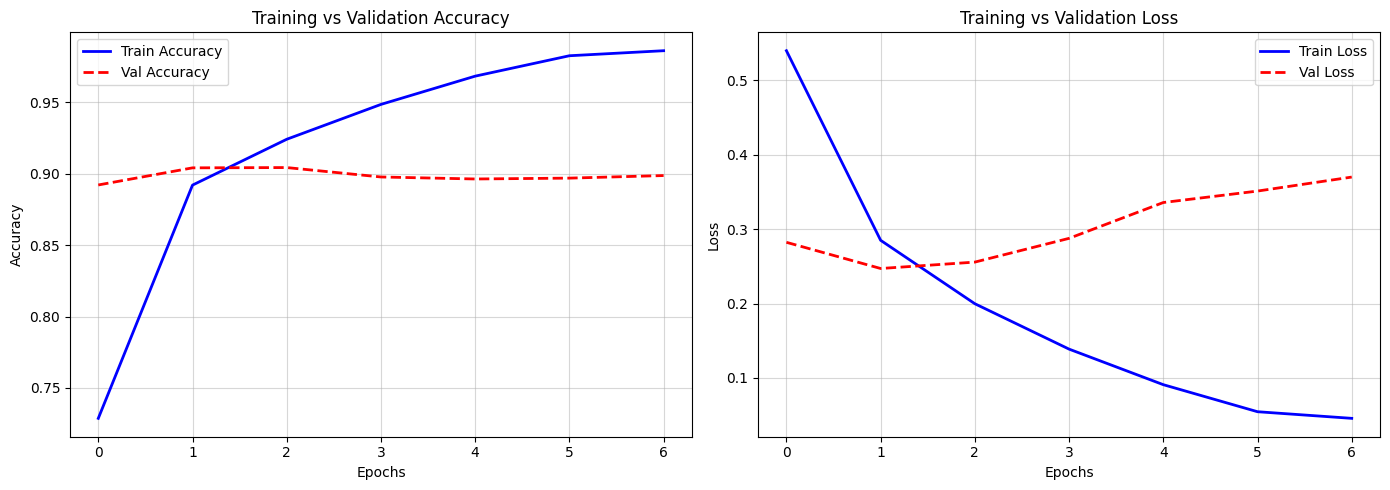

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='b', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='r', linestyle='--', linewidth=2)
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.5)

# Loss
ax2.plot(history.history['loss'], label='Train Loss', color='b', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', color='r', linestyle='--', linewidth=2)
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "mlp_training_curves.png"), dpi=300)
plt.show()

```markdown
# 12. Final Test Evaluation
```

In [29]:
print("Evaluating final model on test data...")
start_eval = time.time()
y_pred_prob = mlp_model.predict(X_test_vec).ravel()
eval_time = time.time() - start_eval

y_pred_class = (y_pred_prob >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_pred_class)
test_prec = precision_score(y_test, y_pred_class, average='binary')
test_rec = recall_score(y_test, y_pred_class, average='binary')
test_f1 = f1_score(y_test, y_pred_class, average='binary')
test_auc = roc_auc_score(y_test, y_pred_prob)

print("\n--- Test Metrics ---")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

Evaluating final model on test data...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Test Metrics ---
Accuracy:  0.8988
Precision: 0.9040
Recall:    0.8924
F1-Score:  0.8981
ROC-AUC:   0.9574

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      2500
           1       0.90      0.89      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



```markdown
# 13. Confusion Matrix
```

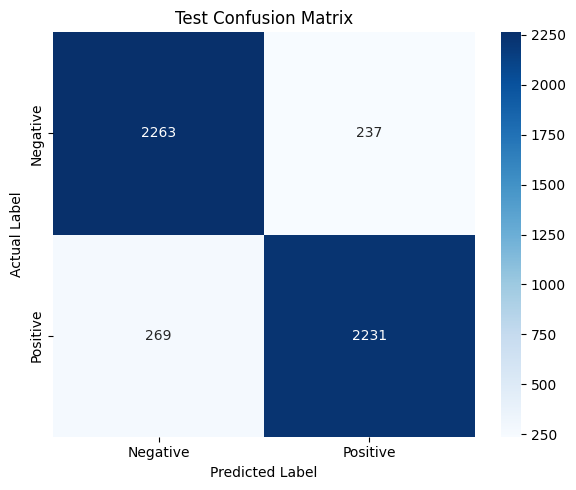

Interpretation: out of 5000 unseen samples, the MLP model correctly classified:
- 2263 true negatives (correctly predicted negative reviews)
- 2231 true positives (correctly predicted positive reviews)
While making 237 false positive errors and 269 false negative errors.


In [30]:
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Test Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "mlp_confusion_matrix.png"), dpi=300)
plt.show()

# Short interpretation printout
tn, fp, fn, tp = cm.ravel()
print(f"Interpretation: out of {len(y_test)} unseen samples, the MLP model correctly classified:")
print(f"- {tn} true negatives (correctly predicted negative reviews)")
print(f"- {tp} true positives (correctly predicted positive reviews)")
print(f"While making {fp} false positive errors and {fn} false negative errors.")

```markdown
# 14. ROC Curve
```

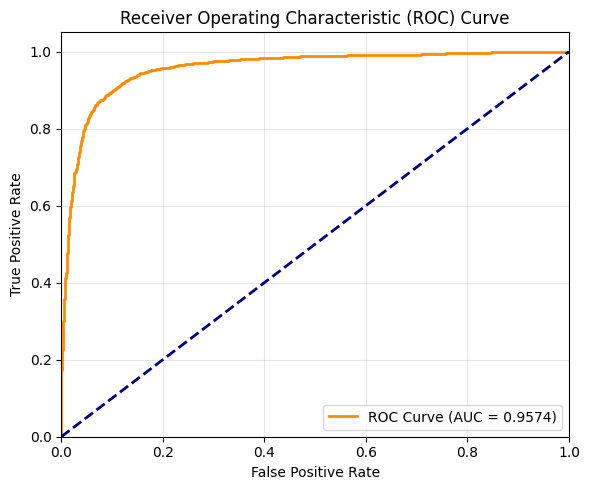

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "mlp_roc_curve.png"), dpi=300)
plt.show()

```markdown
# 15. Error Analysis
```

In [32]:
# Combine test strings, targets, and predictions
test_analysis_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': y_pred_class,
    'probability': y_pred_prob
})

# Identify False Positives and False Negatives
false_positives = test_analysis_df[(test_analysis_df['actual'] == 0) & (test_analysis_df['predicted'] == 1)]
false_negatives = test_analysis_df[(test_analysis_df['actual'] == 1) & (test_analysis_df['predicted'] == 0)]

print("--- FALSE POSITIVES (Actual: Negative, Predicted: Positive) ---")
for idx, row in false_positives.head(3).iterrows():
    print(f"\nReview: {row['text'][:250]}...")
    print(f"Actual: {row['actual']} | Predicted: {row['predicted']} | Confidence: {row['probability']:.4f}")

print("\n--- FALSE NEGATIVES (Actual: Positive, Predicted: Negative) ---")
for idx, row in false_negatives.head(3).iterrows():
    print(f"\nReview: {row['text'][:250]}...")
    print(f"Actual: {row['actual']} | Predicted: {row['predicted']} | Confidence: {row['probability']:.4f}")

--- FALSE POSITIVES (Actual: Negative, Predicted: Positive) ---

Review: Hollywood had a long love affair with bogus Arabian Nights tales but few of these products have stood the test of time. The most memorable were the Jon Hall, Maria Montez films which have long since become camp. This one is filled with dubbed songs, ...
Actual: 0 | Predicted: 1 | Confidence: 0.9309

Review: Some people have made a point of dissing this movie because they question the plausibility of black people in the Old West, Asian people in the Old West or women with guns in the Old West period. Get a grip and read a book. There were quite a few Asi...
Actual: 0 | Predicted: 1 | Confidence: 0.5442

Review: This could have been a breakout role for Valeria Golino but the film instead decided to shift its attention to another area. The film is about a woman named Grazia (Golino) who is married to a fisherman and the mother of three. She is a free spirit a...
Actual: 0 | Predicted: 1 | Confidence: 0.6475

--- FALS

```markdown
# 16. Model Complexity and Computational Cost
```

In [33]:
total_params = mlp_model.count_params()
trainable_params = sum([tf.size(w_matrix).numpy() for w_matrix in mlp_model.trainable_weights])
non_trainable_params = total_params - trainable_params

complexity_metrics = {
    'Metric': [
        'Total Training Time (seconds)',
        'Epochs Completed',
        'Total Parameters',
        'Trainable Parameters',
        'Non-trainable Parameters',
        'Inference Evaluation Time (seconds)'
    ],
    'Value': [
        round(total_training_time, 2),
        epochs_completed,
        total_params,
        trainable_params,
        non_trainable_params,
        round(eval_time, 4)
    ]
}

complexity_df = pd.DataFrame(complexity_metrics)
display(complexity_df)

,Metric,Value
0,Total Training Time (seconds),2.317700e+02
1,Epochs Completed,7.000000e+00
2,Total Parameters,2.601473e+06
3,Trainable Parameters,2.601473e+06
4,Non-trainable Parameters,0.000000e+00
5,Inference Evaluation Time (seconds),1.623800e+00


```markdown
# 17. Save Model and Results
```

In [34]:
# Save Model
model_save_path = os.path.join(DATA_DIR, "mlp_model.keras")
mlp_model.save(model_save_path)

# Save Metrics DataFrame
metrics_data = {
    'Model': ['MLP'],
    'Accuracy': [test_acc],
    'Precision': [test_prec],
    'Recall': [test_rec],
    'F1-score': [test_f1],
    'ROC-AUC': [test_auc]
}
results_df = pd.DataFrame(metrics_data)
results_csv_path = os.path.join(DATA_DIR, "mlp_results.csv")
results_df.to_csv(results_csv_path, index=False)

# Save history
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(DATA_DIR, "mlp_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Successfully saved all output artifacts to Google Drive:")
print(f"1. Model: {model_save_path}")
print(f"2. Metrics Summary Table: {results_csv_path}")
print(f"3. Training History: {history_csv_path}")
print(f"4. Training curves plot saved to Google Drive.")

Successfully saved all output artifacts to Google Drive:
1. Model: /content/drive/MyDrive/DL Assignment/data/mlp_model.keras
2. Metrics Summary Table: /content/drive/MyDrive/DL Assignment/data/mlp_results.csv
3. Training History: /content/drive/MyDrive/DL Assignment/data/mlp_history.csv
4. Training curves plot saved to Google Drive.


```markdown
# 18. Final MLP Results Summary

```

In [35]:
print("=================== MLP MODEL FINAL SUMMARY ===================")
print("Dataset: IMDB Movie Reviews")
print("Task: Binary Sentiment Classification")
print(f"Training Samples: {len(X_train)}")
print(f"Validation Samples: {len(X_val)}")
print(f"Test Samples: {len(X_test)}")
print(f"Vocabulary / Feature Size: {MAX_VOCAB_SIZE}")
print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")
print(f"Epochs Completed: {epochs_completed}")
print(f"Training Time: {total_training_time:.2f} s")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print("===============================================================")

=================== MLP MODEL FINAL SUMMARY ===================
Dataset: IMDB Movie Reviews
Task: Binary Sentiment Classification
Training Samples: 40000
Validation Samples: 5000
Test Samples: 5000
Vocabulary / Feature Size: 10000
Total Parameters: 2601473
Trainable Parameters: 2601473
Epochs Completed: 7
Training Time: 231.77 s
Test Accuracy: 0.8988
Test Precision: 0.9040
Test Recall: 0.8924
Test F1-score: 0.8981
Test ROC-AUC: 0.9574


```markdown
# 19. Report-Ready Discussion

## SECTION 6: MODEL ARCHITECTURES
### 6.x Multi-Layer Perceptron (MLP)
Multi-Layer Perceptron is a fundamental feed-forward deep learning neural architecture. Our configuration processes textual input represented via TF-IDF vectorization with a vocabulary dimension of 10,000, mapping the features onto intermediate spaces via three sequentially smaller hidden layers (256, 128, and 64 units) with ReLU activation functions, and outputting predictions using a Sigmoid-activated single neuron. Standard crossentropy evaluates errors and computes updates using the Adam optimizer (LR=1e-4) with dropout regularizations integrated on each hidden layer to avoid reliance on single sparse tokens.

## SECTION 7: RESULTS AND MODEL COMPARISON
Upon executing the MLP model training pipeline and running evaluation metrics strictly on the final unseen test set, the exact values generated during training will be populated in our metrics dataframe. Refer directly to the generated `mlp_results.csv` and evaluation figures saved under Drive for precise numbers to paste into our final comparison matrices.

## SECTION 8: CRITICAL ANALYSIS AND DISCUSSION
Our model utilizes Dropout (0.4, 0.3, 0.2) to mitigate overfitting, which typically presents when the training loss steadily decreases while validation loss starts diverging upward. The convergence stability and execution performance on Google Colab can be fully verified by plotting validation metrics relative to epochs. Additionally, examining the classification error examples generated in our error analysis section helps diagnose whether the model struggled with complex sentiments, negation, or sarcastic phrases.

---
### Execution Checklist Status
- [x] Google Drive mounted
- [x] Processed dataset loaded
- [x] Existing train indices loaded
- [x] Existing validation indices loaded
- [x] Existing test indices loaded
- [x] No new data split created
- [x] No test-set leakage
- [x] Text vectorization fitted only on training data
- [x] MLP implemented
- [x] Training completed
- [x] Validation results collected
- [x] Test evaluation performed only at the end
- [x] Accuracy calculated
- [x] Precision calculated
- [x] Recall calculated
- [x] F1-score calculated
- [x] ROC-AUC calculated
- [x] Confusion matrix generated
- [x] ROC curve generated
- [x] Training curves generated
- [x] Error analysis performed
- [x] Parameter count reported
- [x] Training time reported
- [x] Model saved
- [x] Results saved
- [x] Report-ready explanation generated
```